In [1]:
# Setup — all imports live here so the notebook executes top-to-bottom
# without reimporting mid-notebook. When running headlessly (CI, HPC),
# uncomment the ``matplotlib.use('Agg')`` line *before* the pyplot import
# so figures never need an interactive display.
import dataclasses
import logging
import os
import sys
from pathlib import Path

# import matplotlib
# matplotlib.use('Agg')  # enable for headless runs
import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from sklearn.decomposition import PCA, FastICA  # noqa: E402

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    WAVELET_BAND_FREQ_RESOLUTION_HZ,
    analyzers_to_datasets,
    load_analyzers,
    wavelet_transform,
)
from src.analysis.wavelet_ica import zscore_by_time  # noqa: E402
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline

# Subject·Frequency·Channel × Time ICA on Wavelet Power

## Scope

This notebook prepares the data and runs the ICA decomposition on the
`(S × F × C, T)` reshape of the 4-D wavelet power tensor.  Subjects,
frequencies and channels are stacked into the observation axis, while
time alone forms the feature axis:

```
Input:   (n_subjects, n_channels, n_freqs, n_times)  — 4-D wavelet power
Reshape: (n_subjects × n_freqs × n_channels,  n_times)
         ──────────── observations ──────────  features
```

Before reshaping the tensor is **z-scored along the time axis** so that
every `(subject, channel, frequency)` slice has zero mean and unit
variance.

ICA components live in the `T` feature space, so each component is a
**temporal pattern** of length `T`.  Scores keep the full
`(subject, frequency, channel)` structure on the observation axis, so
each subject has their own per-(frequency, channel) weighting on every
component.

## Pipeline

1. Load wavelet power for the chosen condition / music type (cached).
2. Apply subject / channel / time subsets for fast iteration.
3. Z-score along time and reshape to `(S×F×C, T)`.
4. PCA dimensionality reduction.
5. FastICA on the PCA scores.

After the final cell the following variables are available:

| Variable | Shape | Description |
|----------|-------|-------------|
| `bb_data` | `(S, C, F, T)` | Raw 4-D wavelet power tensor |
| `bb_z` | `(S, C, F, T)` | Z-scored 4-D wavelet power tensor |
| `X` | `(S×F×C, T)` | Z-scored reshaped 2-D matrix |
| `pca` | — | Fitted PCA object |
| `pca_scores` | `(S×F×C, K_pca)` | PCA-transformed scores |
| `ica` | — | Fitted FastICA object |
| `ica_scores` | `(S×F×C, K_ica)` | ICA scores (per-observation weights) |
| `ica_components` | `(K_ica, T)` | ICA temporal component patterns |
| `scores_2d` | `(S, F, C, K)` | ICA scores reshaped to subject × freq × channel |
| `components_2d` | `(K, T)` | ICA temporal component patterns |

## Configuration

In [2]:
# ── Experiment configuration ────────────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ────────────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(round((WAVELET_FREQ_MAX - WAVELET_FREQ_MIN) / WAVELET_BAND_FREQ_RESOLUTION_HZ))
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ─────────────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subject subset ───────────────────────────────────────────────────
N_SUBJECTS_SUBSET: int | None = 5

# ── Channel and time subset ─────────────────────────────────────────────
N_CHANNELS_SUBSET: int | None = 32  # first N channels (from 195)
N_TIMES_SUBSET: int | None = 10000  # first N time samples

# ── Decomposition settings ──────────────────────────────────────────────
N_COMPONENTS_PCA = 50  # number of PCA components to retain
N_COMPONENTS_ICA = 10  # number of ICA components to extract
ICA_RANDOM_STATE = 42  # reproducibility

# ── Storage directory ─────────────────────────────────────────────────
WAVELET_DIR: Path = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "wavelet_cache"
)

# ── Plot saving ──────────────────────────────────────────────────────
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR
    / "04-wavelet-ica-analysis"
    / "plots"
    / "time"
    / "pca_ica"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({len(FREQS)} steps)"
)
print(f"PCA components         : {N_COMPONENTS_PCA}")
print(f"ICA components         : {N_COMPONENTS_ICA}")

Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache
Frequencies            : 1.0–70.0 Hz (70 steps)
PCA components         : 50
ICA components         : 10


## Data Loading

In [3]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

# Always limit to first N_SUBJECTS_SUBSET individuals
if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

# Slice to channel subset
if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :N_CHANNELS_SUBSET, :])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

# Slice to time subset
if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :, :N_TIMES_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, {ad.n_features} channels, "
        f"{ad.n_samples} samples"
    )

INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(
INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or Compute Wavelet Transforms

Stored in `WAVELET_DIR/broadband/`.

In [4]:
broadband_datasets = wavelet_transform(
    datasets=datasets,
    freqs=FREQS,
    representation=REPRESENTATION,
    keep_frequency_dim=KEEP_FREQUENCY_DIM,
    reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
    wavelet_dir=WAVELET_DIR / "broadband",
    reuse_wavelets=REUSE_WAVELETS,
)
for label, ad in broadband_datasets.items():
    source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
    print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")

[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


## Dataset Selection

Change `LABEL` to switch between music types.  The remaining cells use
`bb_data` (broadband wavelet power, 4-D) and derived quantities.

In [5]:
LABEL = list(broadband_datasets.keys())[0]

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

print(f"Dataset    : {LABEL}")
print(
    f"Shape      : {bb_data.shape}  (subjects × channels × freqs × times)"
)
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({n_freqs} steps)")

Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


---
## Step 1 — Z-score and Reshape

**Z-scoring** normalises each `(subject, channel, frequency)` time series
to zero mean and unit variance.

**Reshaping** stacks subjects, frequencies and channels together on the
observation axis, leaving time as the feature axis:

```
(S, C, F, T)  →  transpose to  (S, F, C, T)
              →  reshape to     (S × F × C,  T)
                                observations  features
```

Each row of the resulting 2-D matrix is the z-scored power time-course
of a single `(subject, frequency, channel)` triplet.  PCA/ICA will
discover **temporal patterns** of length `T` shared across the
`S × F × C` observations.

In [6]:
# Z-score along time: each (subject, channel, frequency) slice → mean=0, std=1
bb_z = zscore_by_time(bb_data)  # (S, C, F, T)

# Reshape: (S, C, F, T) → transpose → (S, F, C, T) → (S*F*C, T)
bb_z_sfc = bb_z.transpose(0, 2, 1, 3)  # (S, F, C, T)
n_obs = n_subjects * n_freqs * n_channels
n_feat = n_times
X = bb_z_sfc.reshape(n_obs, n_feat)  # (S*F*C, T)

print(f"Reshaped matrix shape : {X.shape}")
print(f"  Observations (S×F×C): {X.shape[0]}")
print(f"  Features     (T)    : {X.shape[1]}")
print(f"Row means  ≈ 0 : {X.mean(axis=1).mean():.6f}")
print(f"Row stds        : {X.std(axis=1).mean():.4f}")

Reshaped matrix shape : (11200, 10000)
  Observations (S×F×C): 11200
  Features     (T)    : 10000
Row means  ≈ 0 : 0.000000
Row stds        : 1.0000


---
## Step 2 — PCA Dimensionality Reduction + ICA Decomposition

We first reduce the `T` feature space to `N_COMPONENTS_PCA`
principal components.  FastICA then rotates the PCA subspace to
maximise statistical independence, yielding `N_COMPONENTS_ICA`
independent temporal components.

**Results:**

| Object | Shape | Description |
|--------|-------|-------------|
| `ica_scores` | `(S×F×C, K)` | Per-observation weight for each IC |
| `ica_components` | `(K, T)` | Temporal pattern of each IC |
| `scores_2d` | `(S, F, C, K)` | ICA scores reshaped to subject × freq × channel |
| `components_2d` | `(K, T)` | ICA temporal components (alias of `ica_components`) |

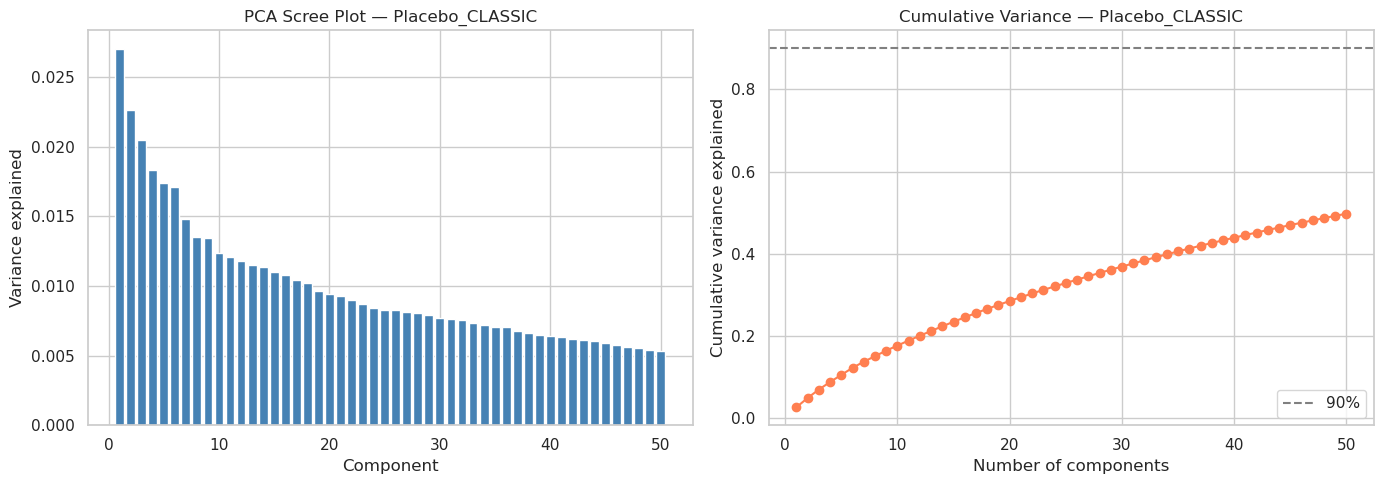

Top 50 components explain 49.8% of total variance.
ICA scores shape       : (11200, 10)
ICA components shape   : (10, 10000)
Scores 2-D shape       : (5, 70, 32, 10)  (S, F, C, K)
Components 2-D shape   : (10, 10000)  (K, T)


In [7]:
# --- PCA ---
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=ICA_RANDOM_STATE)
pca_scores = pca.fit_transform(X)  # (n_obs, K_pca)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title(f"PCA Scree Plot — {LABEL}")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, "o-", color="coral")
axes[1].axhline(0.9, ls="--", color="gray", label="90%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title(f"Cumulative Variance — {LABEL}")
axes[1].legend()

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

print(
    f"Top {N_COMPONENTS_PCA} components explain "
    f"{cumulative[-1] * 100:.1f}% of total variance."
)

# --- ICA ---
ica = FastICA(
    n_components=N_COMPONENTS_ICA,
    random_state=ICA_RANDOM_STATE,
    max_iter=500,
    whiten="unit-variance",
)
ica_scores = ica.fit_transform(pca_scores)  # (S*F*C, K_ica)
ica_components = ica.components_ @ pca.components_  # (K_ica, T)

# Reshape ICA scores to (S, F, C, K) for downstream analysis
scores_2d = ica_scores.reshape(
    n_subjects, n_freqs, n_channels, N_COMPONENTS_ICA
)  # (S, F, C, K)

# Components already live in T directly
components_2d = ica_components  # (K, T)

print(f"ICA scores shape       : {ica_scores.shape}")
print(f"ICA components shape   : {ica_components.shape}")
print(f"Scores 2-D shape       : {scores_2d.shape}  (S, F, C, K)")
print(f"Components 2-D shape   : {components_2d.shape}  (K, T)")

---
## Analysis (a) — Intersubject Correlation Matrix

For each ICA component we compute a **subject × subject** Pearson
correlation matrix.  Each subject is represented by their
**(frequency × channel)** score map for that component, flattened to a
vector of length `F × C`.

High off-diagonal correlations indicate that the component activates
the same frequency–channel pattern across individuals — a hallmark of
a stimulus-driven mode.

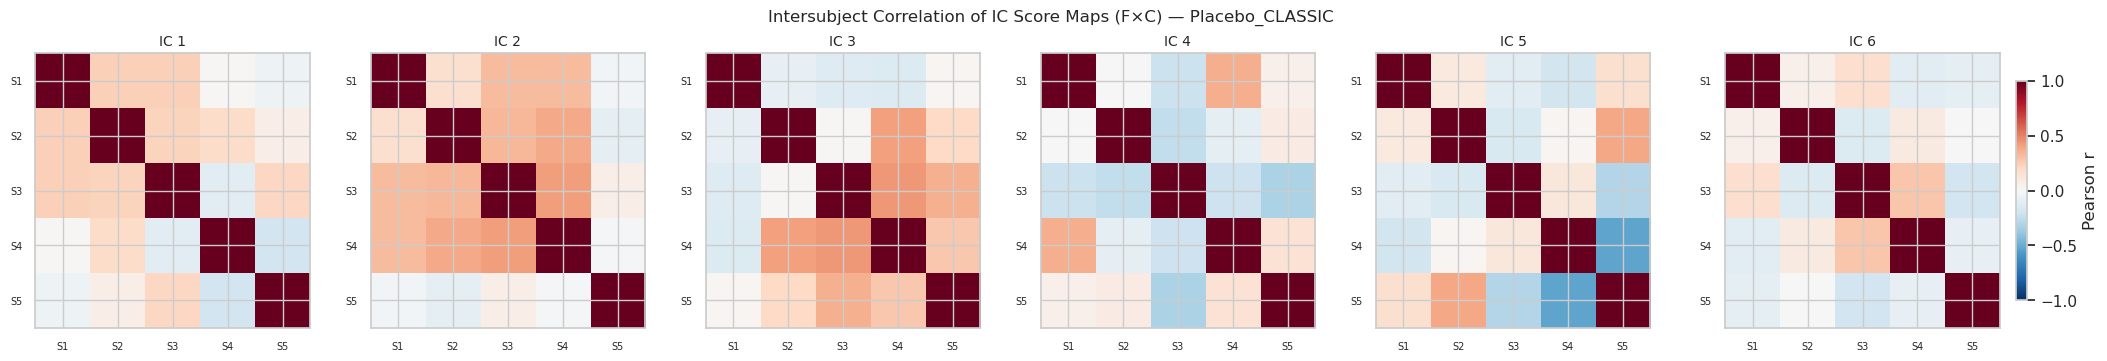

In [8]:
n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    1, n_show, figsize=(3.5 * n_show, 3.5), constrained_layout=True
)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # scores_2d[:, :, :, i] has shape (S, F, C); flatten F×C → one row per subject
    subj_maps = scores_2d[:, :, :, i].reshape(n_subjects, -1)  # (S, F*C)
    corr_mat = np.corrcoef(subj_maps)  # (S, S)
    im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(n_subjects))
    ax.set_yticks(range(n_subjects))
    ax.set_xticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
    ax.set_yticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"Intersubject Correlation of IC Score Maps (F×C) — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="Pearson r", shrink=0.8)
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "isc_component_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (b) — Mean Subject Loading per Component

For each ICA component, compute the **mean absolute score** per
subject.  Scores have shape `(S, F, C, K)`, so taking the mean of
absolute values over `(F, C)` gives a scalar per `(subject, component)`
pair — a summary of how strongly each participant expresses the
temporal mode across frequencies and channels.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `subject_loadings` | `(S, K)` | Mean `|score|` over (F, C) per subject and IC |

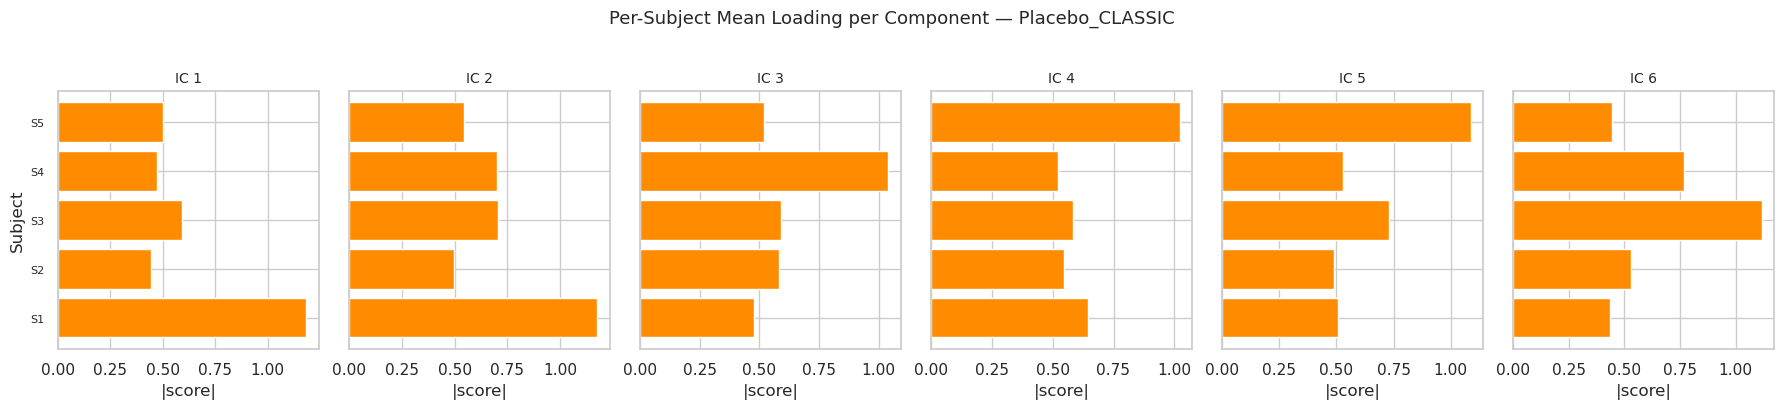

In [9]:
# Subject loadings: mean |score| over (frequencies, channels) per subject
subject_loadings = np.abs(scores_2d).mean(axis=(1, 2))  # (S, K)

n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 4), sharey=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.barh(
        range(n_subjects),
        subject_loadings[:, i],
        color="darkorange",
    )
    ax.set_yticks(range(n_subjects))
    ax.set_yticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=8)
    ax.set_xlabel("|score|")
    ax.set_title(f"IC {i + 1}", fontsize=10)

axes[0].set_ylabel("Subject")
fig.suptitle(
    f"Per-Subject Mean Loading per Component — {LABEL}",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "ica_subject_loadings.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (c) — Time–Frequency Map per Component (Outer Product)

For each ICA component we build a **frequency × time** map directly
from the ICA decomposition:

```
A = scores_2d        # (S, F, C, K)  — per-(subj,freq,chan) score weights
S = components_2d    # (K, T)        — temporal pattern per component

freq_profile[k]  = A[:, :, :, k].mean(axis=(0, 2))   # (F,)  channel-+subject-averaged score
time_profile[k]  = S[k]                              # (T,)  the component itself
tf_map[k]        = outer(freq_profile[k], time_profile[k])  # (F, T)
```

The outer product gives a rank-1 approximation of the component's
frequency–time structure grounded entirely in the ICA solution.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `freq_profiles` | `(F, K)` | Subject- and channel-averaged ICA score per frequency |
| `time_profiles` | `(K, T)` | ICA temporal component (alias of `components_2d`) |
| `ft_maps` | `(K, F, T)` | Outer-product frequency × time map per component |

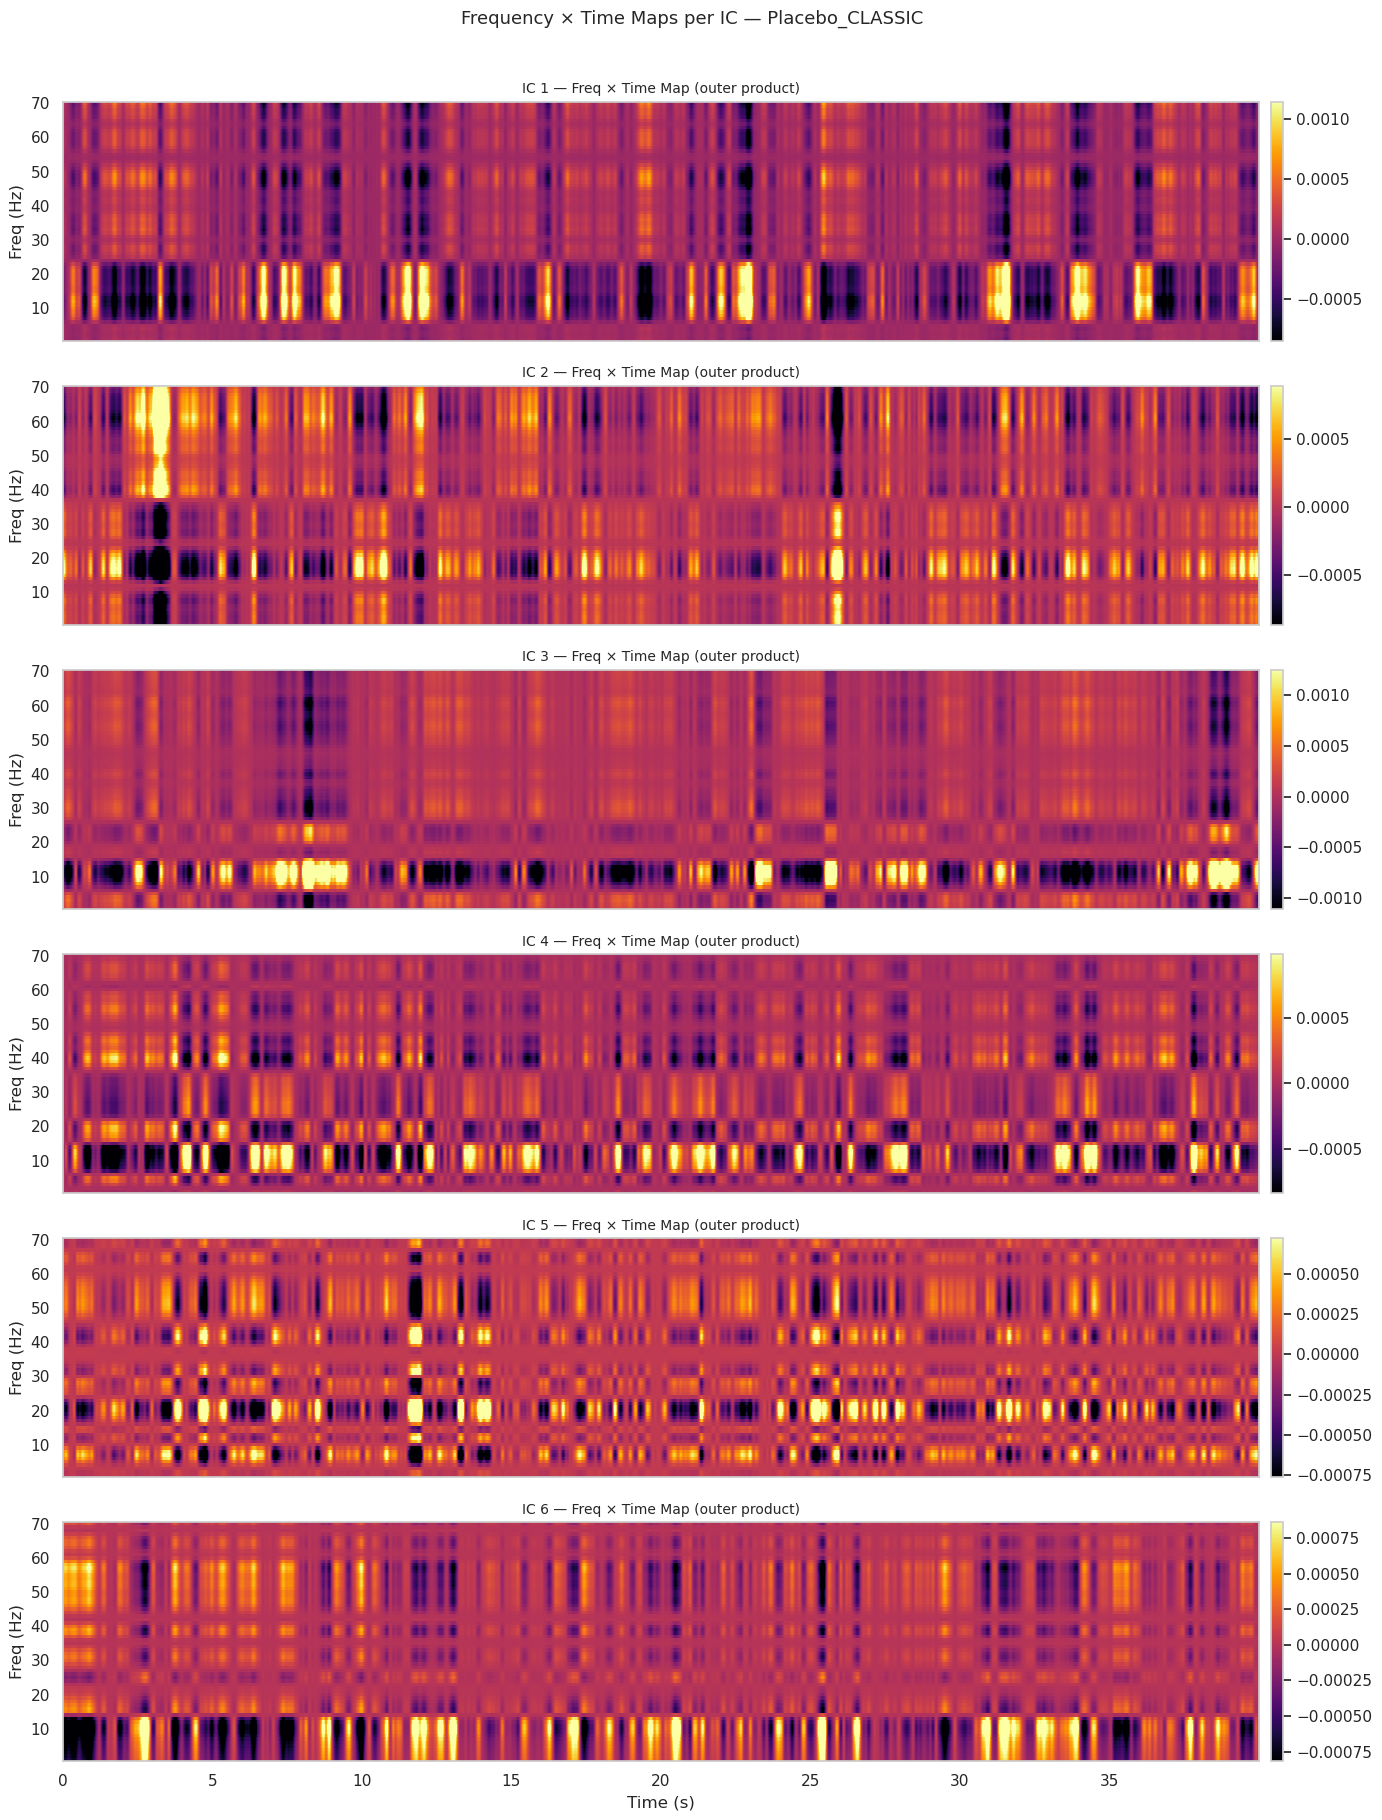

In [10]:
n_show = min(6, N_COMPONENTS_ICA)

# Frequency profile: collapse subjects and channels from ICA scores  (S,F,C,K) → (F,K)
freq_profiles = scores_2d.mean(axis=(0, 2))  # (F, K)

# Time profile: the temporal component itself
time_profiles = components_2d  # (K, T)

# Outer product for each component: (F, K) x (K, T) → (K, F, T)
ft_maps = np.einsum("fk,kt->kft", freq_profiles, time_profiles)  # (K, F, T)

fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    data_i = ft_maps[i]  # (F, T)
    vmin_s, vmax_s = np.percentile(data_i, 1), np.percentile(data_i, 99)
    mesh = ax.pcolormesh(
        time,
        FREQS,
        data_i,
        cmap="inferno",
        vmin=vmin_s,
        vmax=vmax_s,
        shading="auto",
    )
    ax.set_ylabel("Freq (Hz)")
    ax.set_title(f"IC {i + 1} — Freq × Time Map (outer product)", fontsize=10)
    fig.colorbar(mesh, ax=ax, pad=0.01, fraction=0.025)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Frequency × Time Maps per IC — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "ica_time_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (d) — Mean Component Channel Loading (Topomap)

Each ICA component lives in the temporal space `(T,)`, while the
spatial pattern is encoded in the scores `(S, F, C, K)`.  We build a
**per-subject topomap** purely from the ICA outputs, by averaging the
score over frequencies for each subject:

```
A = scores_2d                                    # (S, F, C, K)

topo_per_subj[k, s, c] = A[s, :, c, k].mean(axis=0)   # mean over F  → (K, S, C)
```

Averaging across subjects gives the **average spatial fingerprint** of
each component, plotted as a topomap (`RdBu_r`, symmetric scale).

| Quantity | Shape | Description |
|----------|-------|-------------|
| `topo_per_subj` | `(K, S, C)` | Per-subject topomap per IC (freq-averaged score) |
| `ica_ch_mean` | `(C, K)` | Mean topomap across subjects |

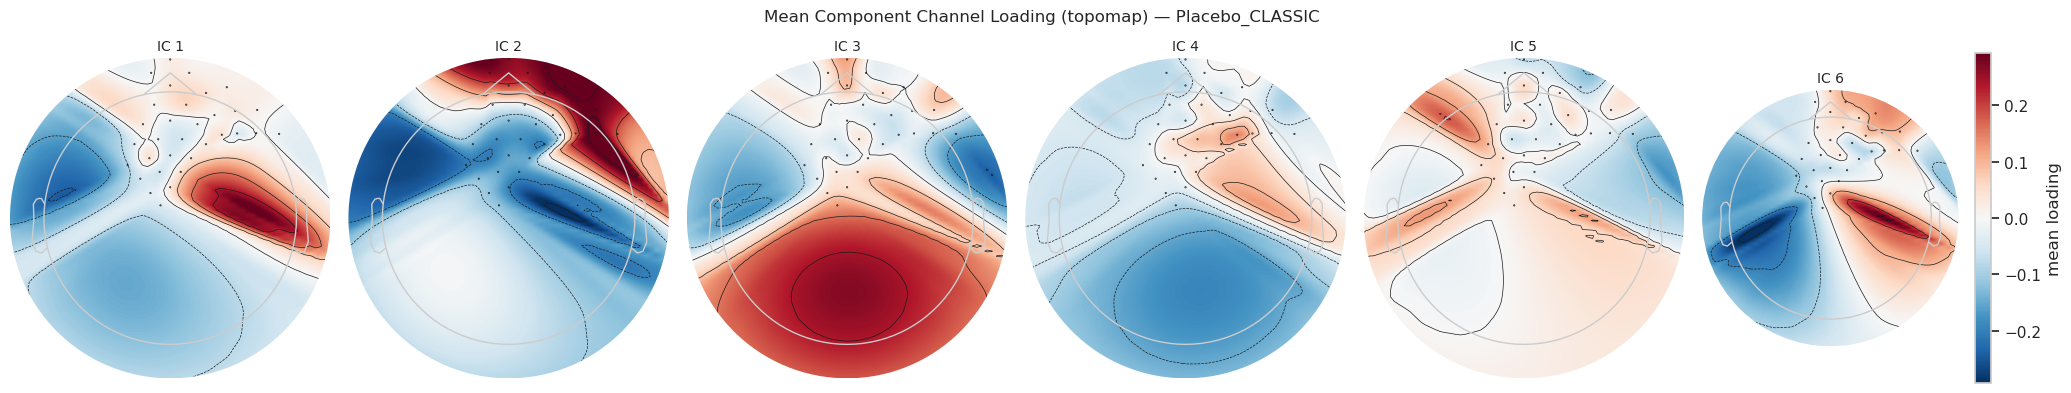

In [11]:
# Per-subject topomap: average score over frequencies — (S, F, C, K) → (K, S, C)
topo_per_subj = scores_2d.mean(axis=1).transpose(2, 0, 1)  # (K, S, C)

# Mean across subjects — equal weight per subject; transpose to (C, K)
ica_ch_mean = topo_per_subj.mean(axis=1).T  # (C, K)

# Get MNE Info for topomap (restrict to the channel subset used here)
info = analyzers[LABEL].info
info = mne.pick_info(info, mne.pick_types(info, eeg=True))
if n_channels < len(info.ch_names):
    info = mne.pick_info(info, list(range(n_channels)))

n_show = min(6, N_COMPONENTS_ICA)

# Symmetric color limits around zero across the displayed components
_vlim_mean = np.percentile(np.abs(ica_ch_mean[:, :n_show]), 99)

fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
if n_show == 1:
    axes = [axes]

im = None
for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        ica_ch_mean[:, i],
        info,
        axes=ax,
        show=False,
        cmap="RdBu_r",
        vlim=(-_vlim_mean, _vlim_mean),
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"Mean Component Channel Loading (topomap) — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="mean loading")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "ica_topomap_mean.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (e) — Mean and Variance of IC Signal Over Time Across Subjects

The temporal component is shared across subjects, so per-subject
temporal activations are reconstructed by scaling the component by each
subject's overall score on that component:

```
subj_score[s, k]   = mean_(f,c) [ scores_2d(s, f, c, k) ]    # (S, K)
per_subj[s, k, t]  = subj_score[s, k] * components_2d[k, t]  # (S, K, T)

mean_temporal[k, t] = mean_s [ per_subj[s, k, t] ]   # (K, T)
var_temporal[k, t]  = var_s  [ per_subj[s, k, t] ]   # (K, T)
std_temporal[k, t]  = sqrt(var_temporal[k, t])       # (K, T)
```

The **mean** is plotted as a line; the **variance** is shown as an
error-shading band around the mean (`mean ± std`).  Wide bands mark
moments of high cross-subject divergence (driven by score
heterogeneity); narrow bands mark cross-subject consensus.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `mean_temporal` | `(K, T)` | Mean per-subject IC activation over subjects |
| `var_temporal` | `(K, T)` | Variance of per-subject IC activation across subjects |
| `std_temporal` | `(K, T)` | Standard deviation, used as the error-band width |

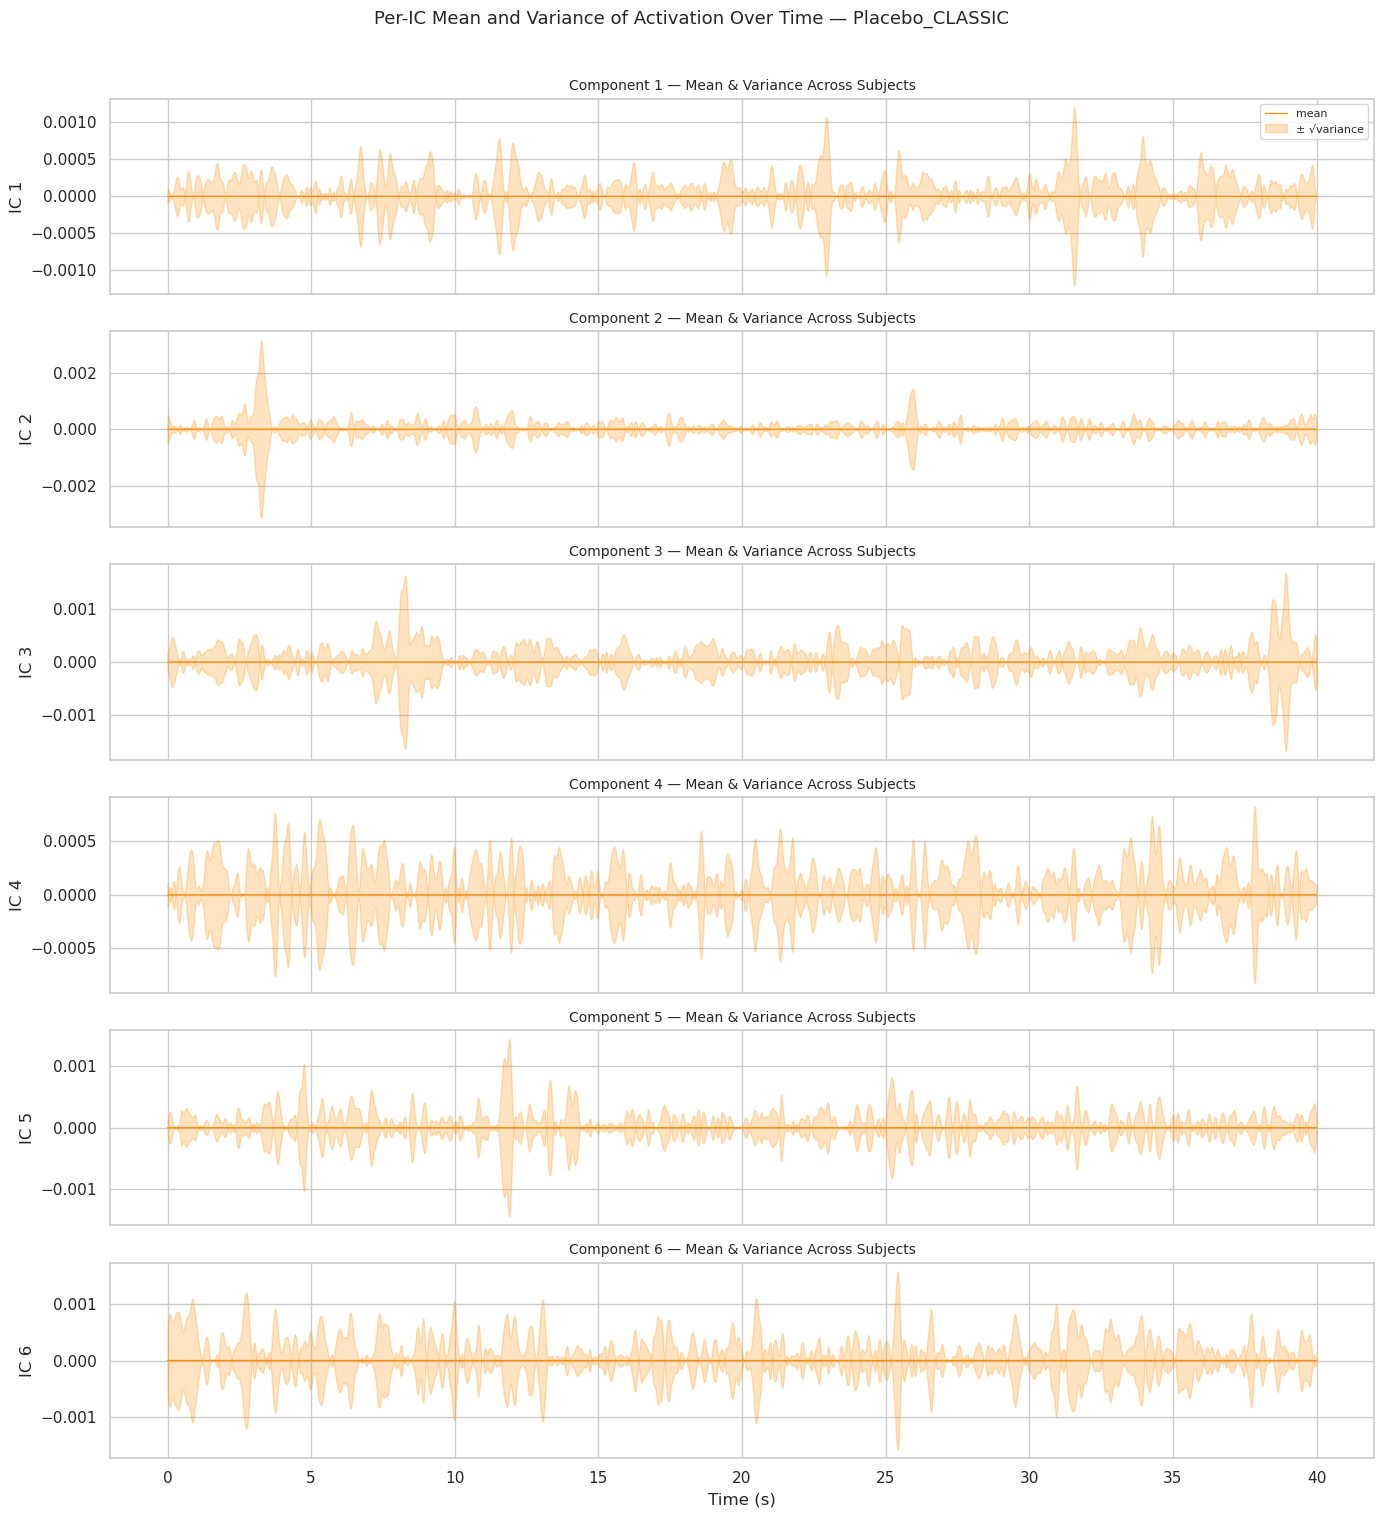

In [12]:
# Per-subject overall score on each IC (mean over freqs, channels)
subj_score = scores_2d.mean(axis=(1, 2))  # (S, K)

# Per-subject temporal activation = subject score × shared temporal component
per_subj_temporal = np.einsum("sk,kt->skt", subj_score, components_2d)  # (S, K, T)

# Across-subject summaries
mean_temporal = per_subj_temporal.mean(axis=0)  # (K, T)
var_temporal = per_subj_temporal.var(axis=0)  # (K, T)
std_temporal = np.sqrt(var_temporal)  # (K, T)

n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(time, mean_temporal[i], lw=0.9, color="darkorange", label="mean")
    ax.fill_between(
        time,
        mean_temporal[i] - std_temporal[i],
        mean_temporal[i] + std_temporal[i],
        alpha=0.25,
        color="darkorange",
        label="± √variance",
    )
    ax.set_ylabel(f"IC {i + 1}")
    ax.set_title(f"Component {i + 1} — Mean & Variance Across Subjects", fontsize=10)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-IC Mean and Variance of Activation Over Time — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_mean_variance_over_time.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()
plt.close("all")